In [1]:
import cme.decision_models.diffusion_discrete as dd
import cme.decision_models.quantum_discrete as qd
import jax.numpy as npx
import jax.scipy as sci
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
n_states, start_width, mu, sigma, delta = 7,1, npx.asarray([[2]]), npx.asarray([[1]]), 1

# Transition Matrix

In [3]:
d_K = dd._buildK(n_states, mu, sigma).squeeze()
d_K

Array([[-1. , -0.5,  0. ,  0. ,  0. ,  0. ,  0. ],
       [ 1. , -1. , -0.5,  0. ,  0. ,  0. ,  0. ],
       [ 0. ,  1.5, -1. , -0.5,  0. ,  0. ,  0. ],
       [ 0. ,  0. ,  1.5, -1. , -0.5,  0. ,  0. ],
       [ 0. ,  0. ,  0. ,  1.5, -1. , -0.5,  0. ],
       [ 0. ,  0. ,  0. ,  0. ,  1.5, -1. ,  1. ],
       [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -1. ]], dtype=float64)

In [4]:
q_H = qd._buildH(n_states, mu, sigma).squeeze()
q_H

Array([[-6.,  1.,  0.,  0.,  0.,  0.,  0.],
       [ 1., -4.,  1.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -2.,  1.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  1.,  2.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  1.,  4.,  1.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  6.]], dtype=float64)

# Starting Point

In [5]:
d_init = dd._get_initial_state(n_states, start_width).squeeze()
d_init

Array([0.        , 0.        , 0.33333333, 0.33333333, 0.33333333,
       0.        , 0.        ], dtype=float64)

In [6]:
q_init = qd._get_initial_state(n_states, start_width).squeeze()
q_init

Array([0.        , 0.        , 0.57735027, 0.57735027, 0.57735027,
       0.        , 0.        ], dtype=float64)

# Measurement Matrix

In [7]:
d_Mc, d_Mw, d_Mnor = dd._get_measurement_matrix(n_states, start_width,prob=0.25)
d_Mc+ d_Mw+ d_Mnor

Array([[1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.]], dtype=float64)

In [8]:
q_Mc, q_Mw, q_Mnor = qd._get_measurement_matrix(n_states, start_width,prob=0.25)
q_Mc**2 + q_Mw**2 + q_Mnor**2

Array([[1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1.]], dtype=float64)

# No Interference and No Noise (not a Hidden Markov Model)

## Transition State Matrix at a response time

In [9]:
rt = 20

In [10]:
d_Tr = sci.linalg.expm(rt * d_K)
d_Tr 

Array([[-0.00274725, -0.00274725, -0.00274725, -0.00274725, -0.00274725,
        -0.00274725, -0.00274725],
       [ 0.0054945 ,  0.00549451,  0.00549451,  0.00549451,  0.00549451,
         0.00549451,  0.00549451],
       [-0.01648351, -0.01648352, -0.01648352, -0.01648352, -0.01648352,
        -0.01648352, -0.01648352],
       [ 0.04945055,  0.04945055,  0.04945055,  0.04945055,  0.04945055,
         0.04945055,  0.04945055],
       [-0.14835164, -0.14835165, -0.14835165, -0.14835165, -0.14835165,
        -0.14835165, -0.14835165],
       [ 0.44505495,  0.44505495,  0.44505495,  0.44505494,  0.44505494,
         0.44505495,  0.44505494],
       [ 0.66758241,  0.66758242,  0.66758241,  0.66758242,  0.66758242,
         0.66758242,  0.66758242]], dtype=float64)

In [11]:
q_Tr = sci.linalg.expm(-1j * rt * q_H)
q_Tr 

Array([[-0.69191385-2.75813323e-01j,  0.56775572-1.04390093e-01j,
        -0.26715903+1.63106166e-01j,  0.09507058-6.37415355e-02j,
        -0.02580723+1.26960392e-02j,  0.00545634-1.26960392e-03j,
        -0.00090939+5.40597263e-18j],
       [ 0.56775572-1.04390093e-01j,  0.17643856-3.21487342e-01j,
        -0.40580981+4.84293037e-01j,  0.27745724-2.06647007e-01j,
        -0.10593093+3.65571744e-02j,  0.02784682-6.80675676e-18j,
        -0.00545634-1.26960392e-03j],
       [-0.26715903+1.63106166e-01j, -0.40580981+4.84293037e-01j,
        -0.09056478+2.77345558e-01j,  0.50301766-2.41996283e-01j,
        -0.30447429+3.11708125e-16j,  0.10593093+3.65571744e-02j,
        -0.02580723-1.26960392e-02j],
       [ 0.09507058-6.37415355e-02j,  0.27745724-2.06647007e-01j,
         0.50301766-2.41996283e-01j,  0.33353899-1.57187631e-15j,
        -0.50301766-2.41996283e-01j,  0.27745724+2.06647007e-01j,
        -0.09507058-6.37415355e-02j],
       [-0.02580723+1.26960392e-02j, -0.10593093+3.65571

## Probability

In [12]:
d_P = d_Tr @ d_init
d_P

Array([-0.00274725,  0.00549451, -0.01648352,  0.04945055, -0.14835165,
        0.44505494,  0.66758242], dtype=float64)

In [13]:
q_P = npx.abs(q_Tr @ q_init)**2
q_P

Array([0.0172401 , 0.05120414, 0.00430298, 0.11516569, 0.35874061,
       0.38402855, 0.06931793], dtype=float64)

## Mean Confidence

In [14]:
Mid = (n_states + 1)//2
mv = npx.arange(-(Mid-1), (Mid))[None,:]
mv

Array([[-3, -2, -1,  0,  1,  2,  3]], dtype=int64)

In [15]:
mv.shape, d_P.shape, q_P.shape

((1, 7), (7,), (7,))

In [16]:
d_Mconf = mv @ d_P
d_Mconf

Array([2.75824175], dtype=float64)

In [17]:
q_Mconf = mv @ q_P
q_Mconf

Array([1.17631997], dtype=float64)

# With State Collapse (only No Response)

## Transition State Matrix at a response time

In [18]:
delta_ratio = .25 # Suggesting interference happended at the middle of response time 
delta = rt*delta_ratio
delta

5.0

In [19]:
d_Tr_delta = sci.linalg.expm(delta * d_K)

In [20]:
q_Tr_delta = sci.linalg.expm(-1j * delta * q_H)

In [21]:
n = rt/delta
n

4.0

In [22]:
d_Tr = d_Tr_delta @ npx.linalg.matrix_power(d_Mnor @ d_Tr_delta, int(np.ceil(n)-1))

In [23]:
q_Tr = q_Tr_delta @ npx.linalg.matrix_power(q_Mnor @ q_Tr_delta, int(np.ceil(n)-1))

### Probability

In [24]:
d_P = d_Tr @ d_init

In [25]:
q_P = npx.abs(q_Tr @ q_init)**2

### Mean Confidence

In [26]:
mv.shape, d_P.shape, q_P.shape

((1, 7), (7,), (7,))

In [27]:
d_Mconf = mv @ d_P
d_Mconf

Array([1.59989135], dtype=float64)

In [28]:
q_Mconf = mv @ q_P
q_Mconf

Array([1.14825418], dtype=float64)

# Integrating over all possible responses at each interference

(see Busemeyer 2019, Eqs 1,2,3,4 for more information)

## Probability

In [35]:
rt=20
delta_ratio = 0.1 # Suggesting interference happended at the middle of response time 
delta = rt*delta_ratio
n = rt/delta

rt, delta, np.ceil(n)

(20, 2.0, 10.0)

In [36]:
mv @ sci.linalg.expm(rt * d_K) @ d_init

Array([2.75824175], dtype=float64)

Unless intensity matrix changes (as created above), all values of delta should result in 2.75824175 mean confidence.

In [37]:
d_Tr_delta = sci.linalg.expm(delta * d_K)

d_P = (npx.linalg.matrix_power(d_Mnor @ d_Tr_delta 
                                + d_Mc @ d_Tr_delta 
                                + d_Mw @ d_Tr_delta, 
                                 int(np.ceil(n))) 
        @ d_init)
mv @ d_P

Array([2.75824175], dtype=float64)

d_P_nor = (npx.linalg.matrix_power(d_Mnor @ d_Tr_delta, int(np.ceil(n))) @ d_init)
d_P_c = (npx.linalg.matrix_power(d_Mc @ d_Tr_delta, int(np.ceil(n))) @ d_init)
d_P_w = (npx.linalg.matrix_power(d_Mw @ d_Tr_delta, int(np.ceil(n))) @ d_init)

d_P = d_P_nor + d_P_w + d_P_c

mv @ d_P

The mean confidence should be 1.17631997

In [39]:
mv @ npx.abs(sci.linalg.expm(-1j * rt * q_H) @ q_init)**2

Array([1.17631997], dtype=float64)

In [40]:
q_Tr_delta = sci.linalg.expm(-1j * delta * q_H)
q_Tr = (npx.linalg.matrix_power(q_Mnor @ q_Tr_delta 
                                  + q_Mc @ q_Tr_delta 
                                  + q_Mw @ q_Tr_delta, 
                                int(np.ceil(n)))
        @ q_init
        )
                    
q_P = npx.abs(q_Tr )**2
mv @ (q_P), q_P.sum()

(Array([2.58520073], dtype=float64), Array(2.90400944, dtype=float64))

Let's add probabilities and not amplitude

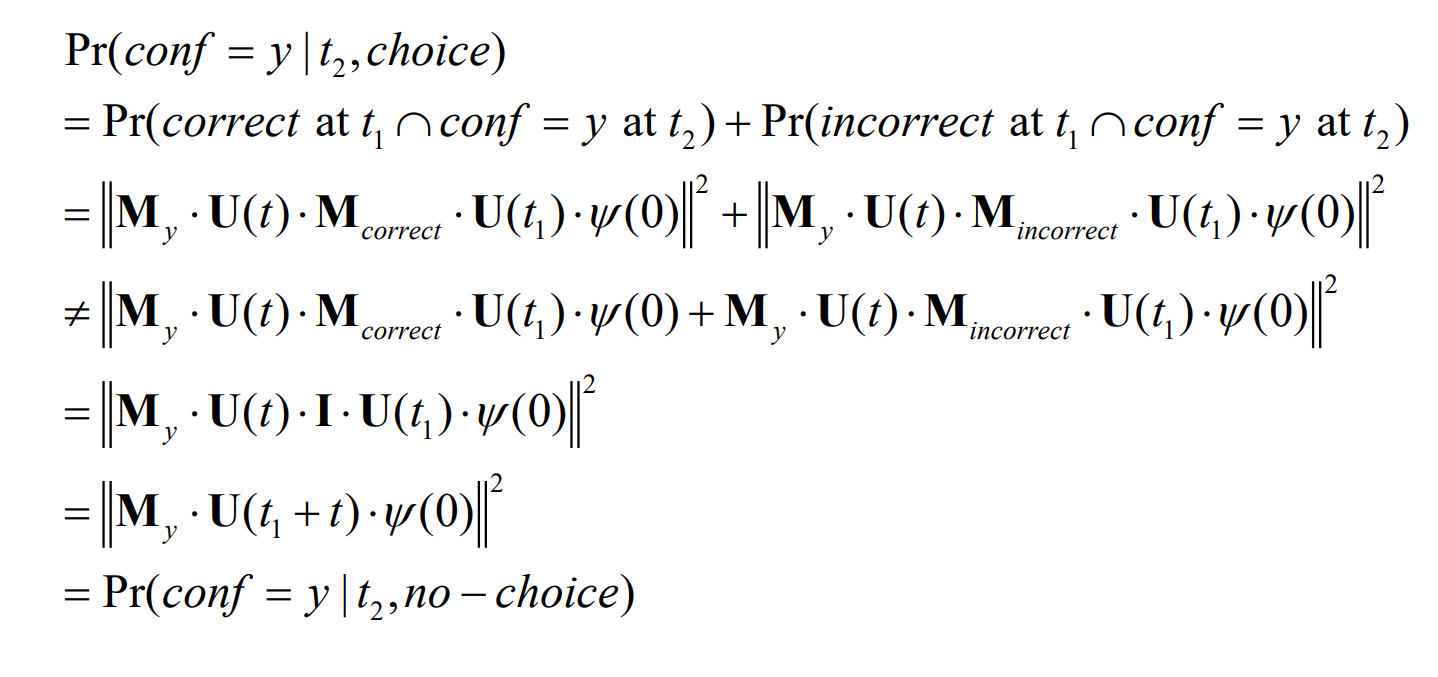

In [ ]:
q_Tr_delta = sci.linalg.expm(-1j * delta * q_H)

q_Tr_nor = (npx.linalg.matrix_power(q_Mnor @ q_Tr_delta, int(np.ceil(n))) @ q_init )
q_P_nor = npx.abs(q_Tr_nor)**2
q_Tr_c = (npx.linalg.matrix_power(q_Mc @ q_Tr_delta, int(np.ceil(n))) @ q_init )
q_P_c = npx.abs(q_Tr_c)**2
q_Tr_w = (npx.linalg.matrix_power(q_Mw @ q_Tr_delta, int(np.ceil(n))) @ q_init )
q_P_w = npx.abs(q_Tr_w)**2

q_P = q_P_nor + q_P_c + q_P_w

mv @ (q_P), q_P.sum()

# Examine Over Time

In [ ]:
Mid = (n_states + 1)//2

#1xn
mv = npx.arange(-(Mid-1), (Mid))[None,:]
delta=1

In [ ]:
rt=20
delta_ratio = 1 # Suggesting interference happended at the middle of response time 
delta = rt*delta_ratio
#n = rt/delta

rt, delta

In [ ]:
df_interference = pd.DataFrame()

for r in range(delta, rt, delta):
    markov_no_interference = mv @ sci.linalg.expm(r * d_K) @ d_init

    d_Tr_delta = sci.linalg.expm(delta * d_K)
    n = r/delta
    d_P = (npx.linalg.matrix_power(d_Mnor @ d_Tr_delta 
                                    + d_Mc @ d_Tr_delta 
                                    + d_Mw @ d_Tr_delta, 
                                    int(np.ceil(n))) 
            @ d_init)
    markov_with_interference = mv @ d_P



    quantum_no_interference = mv @ npx.abs(sci.linalg.expm(-1j * r * q_H) @ q_init)**2
    n = r/delta
    q_Tr_delta = sci.linalg.expm(-1j * delta * q_H)
    q_Tr = (npx.linalg.matrix_power(q_Mnor @ q_Tr_delta 
                                    + q_Mc @ q_Tr_delta 
                                    + q_Mw @ q_Tr_delta, 
                                    int(np.ceil(n)))
            @ q_init
            )
                        
    q_P = npx.abs(q_Tr )**2
    quantum_with_interference = mv @ (q_P/q_P.sum())
    
    


## No State Collapse
State measured only at the end of response time

In [ ]:
df_conf = pd.DataFrame()
delta=0.01
rt=20
for r in npx.arange(delta, rt, delta):
    #nxn
    d_Tr = sci.linalg.expm(r * d_K) 
    q_Tr = sci.linalg.expm(-1j * r * q_H)

    #nx1
    d_P = d_Tr @ d_init
    q_P = npx.abs(q_Tr @ q_init)**2

    #scaler
    d_Mconf = mv @ d_P
    q_Mconf = mv @ q_P

    df_conf = pd.concat([df_conf, 
                         pd.DataFrame({"rt":np.asarray(r), 
                                       "mean_diffusion_confidence":np.asarray(d_Mconf), 
                                       "mean_quantum_confidence": np.asarray(q_Mconf)}) ])
df_conf

In [ ]:
sns.lineplot(df_conf.melt(id_vars="rt"),
x="rt",
y="value",
hue="variable").set_title("No Interference")

In [ ]:
q_Mnor

In [ ]:
df_conf = pd.DataFrame()
delta=0.1
rt=20
q_init_inter = qd._get_initial_state(n_states, start_width).squeeze()
for r in npx.arange(delta, rt, delta):
    #nxn
    d_Tr = sci.linalg.expm(r * d_K) 
    q_Tr = sci.linalg.expm(-1j * r * q_H)

    #nx1
    d_P = d_Tr @ d_init
    
    #q_init_inter = (q_Tr @ q_init_inter)/npx.sqrt((npx.abs(q_Tr @ q_init_inter)**2).sum())

    q_P = npx.abs(q_Tr @ q_init_inter)**2


    #q_P = npx.abs(q_Tr @ q_init)**2
    #scaler
    d_Mconf = mv @ d_P
    q_Mconf = mv @ q_P

    df_conf = pd.concat([df_conf, 
                         pd.DataFrame({"rt":np.asarray(r), 
                                       "mean_diffusion_confidence":np.asarray(d_Mconf), 
                                       "mean_quantum_confidence": np.asarray(q_Mconf)}) ])
sns.lineplot(df_conf.melt(id_vars="rt"),
x="rt",
y="value",
hue="variable").set_title("No Interference")

In [ ]:
df_conf = pd.DataFrame()
delta=0.1
rt=20
q_init_inter = qd._get_initial_state(n_states, start_width).squeeze()
for r in npx.arange(delta, rt, delta):
    #nxn
    d_Tr = sci.linalg.expm(r * d_K) 
    q_Tr_no = sci.linalg.expm(-1j * r * q_H)
    q_Tr_with = sci.linalg.expm(-1j * r/2 * q_H)

    #nx1
    d_P = d_Tr @ d_init
    
    q_init_inter_with = (q_Mnor @ q_Tr_with @ q_init_inter)/npx.sqrt((npx.abs(q_Mnor @ q_Tr_with @ q_init_inter)**2).sum())
    q_P_with = npx.abs(q_Tr_with @ q_init_inter_with)**2
    
    q_P_no = npx.abs(q_Tr_no @ q_init_inter)**2
    


    #q_P = npx.abs(q_Tr @ q_init)**2
    #scaler
    d_Mconf = mv @ d_P
    q_Mconf_no = mv @ q_P_no
    q_Mconf_with = mv @ q_P_with

    df_conf = pd.concat([df_conf, 
                         pd.DataFrame({"rt":np.asarray(r), 
                                       "mean_diffusion_confidence":np.asarray(d_Mconf), 
                                       "mean_quantum_confidence_No_Interference": np.asarray(q_Mconf_no),
                                       "mean_quantum_confidence_With_Interference": np.asarray(q_Mconf_with)}) ])
sns.lineplot(df_conf.melt(id_vars="rt"),
x="rt",
y="value",
hue="variable").set_title("No Interference")

## With State Collapse

### No Noise

In [ ]:
d_K

In [ ]:
df_conf = pd.DataFrame()
delta = 1
collapse = delta # should be smaller than delta
rt=100
for collapse in [delta]:#, delta/2, delta/10, delta/100]:
    for r in npx.arange(2*delta, rt, delta):

        n = np.ceil(r/collapse)

        #nxn
        d_Tr_delta = sci.linalg.expm(collapse * d_K) 
        q_Tr_delta = sci.linalg.expm(-1j * collapse * q_H)
        d_Tr_no = sci.linalg.expm(r * d_K) 
        q_Tr_no = sci.linalg.expm(-1j * r * q_H)

        #nx1
        d_P_no = d_Tr_no @ d_init
        d_P = d_Tr_delta @ (npx.linalg.matrix_power( d_Mnor @ d_Tr_delta, int(n-1))) @ d_init

        q_Tr = q_Tr_delta @ (npx.linalg.matrix_power(q_Mnor @ q_Tr_delta, int(n-1))) @ q_init
        q_P = npx.abs(q_Tr)**2

        q_P_no = npx.abs(q_Tr_no @ q_init)**2

        #scaler
        d_Mconf_no = mv @ d_P_no
        d_Mconf = mv @ d_P
        q_Mconf = mv @ q_P
        q_Mconf_no = mv @ q_P_no

        df_conf = pd.concat([df_conf, 
                            pd.DataFrame({"rt":np.asarray(r), "n_collapse":collapse,
                                        "mean_diffusion_confidence_no_interference":np.asarray(d_Mconf_no), 
                                        "mean_diffusion_confidence_with_interference":np.asarray(d_Mconf), 
                                        "mean_quantum_confidence_no_interference": np.asarray(q_Mconf_no),
                                        "mean_quantum_confidence_with_interference": np.asarray(q_Mconf)
                                        }) ])

sns.relplot(df_conf.melt(id_vars=["rt", "n_collapse"]),
x="rt",
y="value", hue="n_collapse", kind="line",
col="variable", palette="Set2", facet_kws = {"sharey":False})#.set_title("With Interference")

In [ ]:
(d_Tr_no @ d_init).sum()

In [ ]:
(d_Mnor @ d_Tr_no @ d_init + d_Mc @ d_Tr_no @ d_init + d_Mw @ d_Tr_no @ d_init).sum()

In [ ]:
(npx.abs(q_Mc @ q_Tr_no)**2 + npx.abs(q_Mw @ q_Tr_no)**2 + npx.abs(q_Mnor @ q_Tr_no)**2).sum()

In [ ]:
(npx.abs(q_Tr_no @ q_init)**2).sum()

In [ ]:
r = 1.4
d_init = dd._get_initial_state(n_states, start_width,prob=0.2).squeeze()
q_init = qd._get_initial_state(n_states, start_width,prob=0.2).squeeze()

d_Tr_no = sci.linalg.expm(r * d_K) 
q_Tr_no = sci.linalg.expm(-1j * r * q_H)

#nx1
d_P_no = d_Tr_no @ d_init
d_P = d_Mnor @ d_Tr_no @ d_init + d_Mc @ d_Tr_no @ d_init + d_Mw @ d_Tr_no @ d_init

q_P = npx.abs(q_Mc @ q_Tr_no)**2 + npx.abs(q_Mw @ q_Tr_no)**2 + npx.abs(q_Mnor @ q_Tr_no)**2
q_P_no = npx.abs(q_Tr_no @ q_init)**2

d_Mconf_no = [d_P_no.sum()]
d_Mconf = [d_P.sum()]
q_Mconf = [q_P.sum()]
q_Mconf_no = [q_P_no.sum()]

print(d_Mconf_no,d_Mconf, q_Mconf, q_Mconf_no)

In [ ]:
df_conf = pd.DataFrame()
delta = 1
rt=
for r in npx.arange(delta, rt, delta):

    #nxn

    d_Tr_no = sci.linalg.expm(r * d_K) 
    q_Tr_no = sci.linalg.expm(-1j * r * q_H)

    #nx1
    d_P_no = d_Tr_no @ d_init
    d_P = d_Mnor @ d_Tr_no @ d_init + d_Mc @ d_Tr_no @ d_init + d_Mw @ d_Tr_no @ d_init

    q_P = npx.abs(q_Mc @ q_Tr_no)**2 + npx.abs(q_Mw @ q_Tr_no)**2 + npx.abs(q_Mnor @ q_Tr_no)**2
    q_P_no = npx.abs(q_Tr_no @ q_init)**2

    #scaler
    d_Mconf_no = [d_P_no.sum()]
    d_Mconf = [d_P.sum()]
    q_Mconf = [q_P.sum()]
    q_Mconf_no = [q_P_no.sum()]

    df_conf = pd.concat([df_conf, 
                        pd.DataFrame({"rt":np.asarray(r),
                                    "mean_diffusion_confidence_no_interference":np.asarray(d_Mconf_no), 
                                    "mean_diffusion_confidence_with_interference":np.asarray(d_Mconf), 
                                    "mean_quantum_confidence_no_interference": np.asarray(q_Mconf_no),
                                    "mean_quantum_confidence_with_interference": np.asarray(q_Mconf)
                                    }) ])
df_conf
sns.relplot(df_conf.melt(id_vars=["rt"]),
x="rt",
y="value", kind="line",
col="variable", palette="Set2", facet_kws = {"sharey":False})#.set_title("With Interference")

In [ ]:
df_conf

In [ ]:
n_states, start_width, mu, sigma, delta = 7,1, npx.asarray([[2]]), npx.asarray([[1]]), 1

d_K = dd._buildK(n_states, mu, sigma).squeeze()
q_H = qd._buildH(n_states, mu, sigma).squeeze()

d_Mc, d_Mw, d_Mnor = dd._get_measurement_matrix(n_states, start_width,prob=0.25)
q_Mc, q_Mw, q_Mnor = qd._get_measurement_matrix(n_states, start_width,prob=npx.sqrt(0.25))

